In [1]:
import numpy as np
import matplotlib.pyplot as plt
import core_collapse as cc

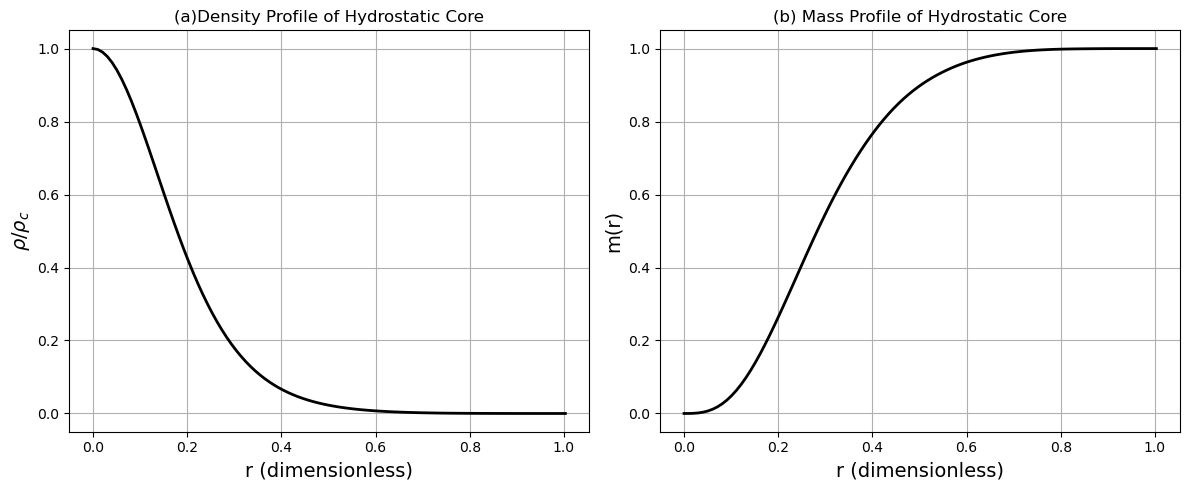

In [13]:
import matplotlib.pyplot as plt

# your data
r, m, rho_desh = cc.lame_emden_solver(nn=3, xi_max=7, NN=101)

# --- Plot ---
plt.figure(figsize=(12,5))

# 1. Density profile
plt.subplot(1,2,1)
plt.plot(r, rho_desh, color='black', linewidth=2)
plt.xlabel('r (dimensionless)', fontsize=14)
plt.ylabel(r'$\rho / \rho_c$', fontsize=14)
plt.title('(a)Density Profile of Hydrostatic Core')
plt.grid()

# 2. Mass profile
plt.subplot(1,2,2)
plt.plot(r, m, color='black',linewidth=2)
plt.xlabel('r (dimensionless)', fontsize=14)
plt.ylabel('m(r)', fontsize=14)
plt.title('(b) Mass Profile of Hydrostatic Core')
plt.grid()

plt.tight_layout()
plt.tight_layout()
plt.savefig("lane_emden_profiles.png", dpi=300, bbox_inches='tight')
plt.show()



0.009999344988574936


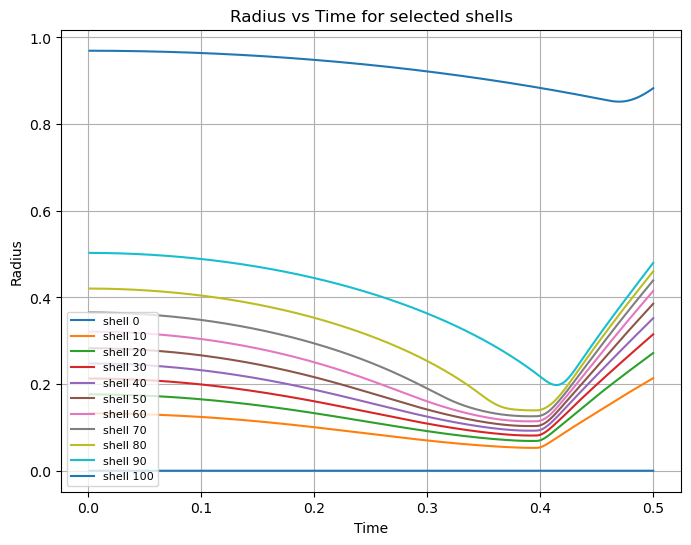

In [20]:
t_arr, r_arr, v_arr, p_arr, rho_arr, e_arr, cs_arr = cc.collapse_simulation(lambda: cc.initialise_white_dwarf2(100), t_end=0.5)
shell_indices = np.arange(0, r_arr.shape[1], 10)

plt.figure(figsize=(8, 6))
for i in shell_indices:
    plt.plot(t_arr, r_arr[:, i], label=f"shell {i}")

plt.xlabel("Time")
plt.ylabel("Radius")
plt.title("Radius vs Time for selected shells")
plt.legend(loc="lower left", fontsize=8)
plt.grid()

plt.show()

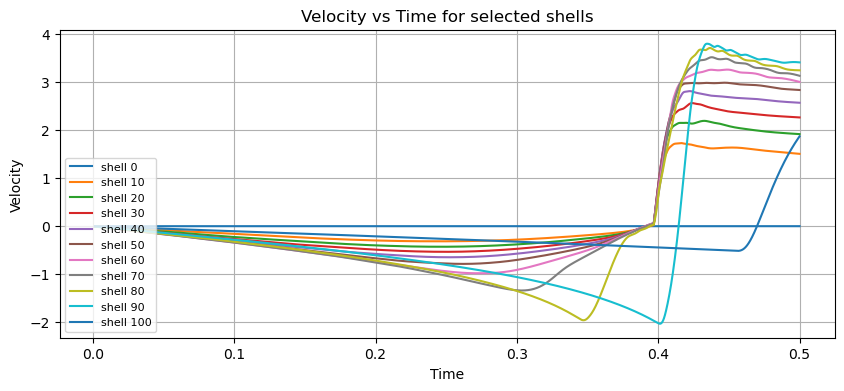

In [21]:
plt.figure(figsize=(10, 4))
for i in shell_indices:
    plt.plot(t_arr, v_arr[:, i], label=f"shell {i}")

plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Velocity vs Time for selected shells")
plt.legend(loc="lower left", fontsize=8)
plt.grid()

plt.show()

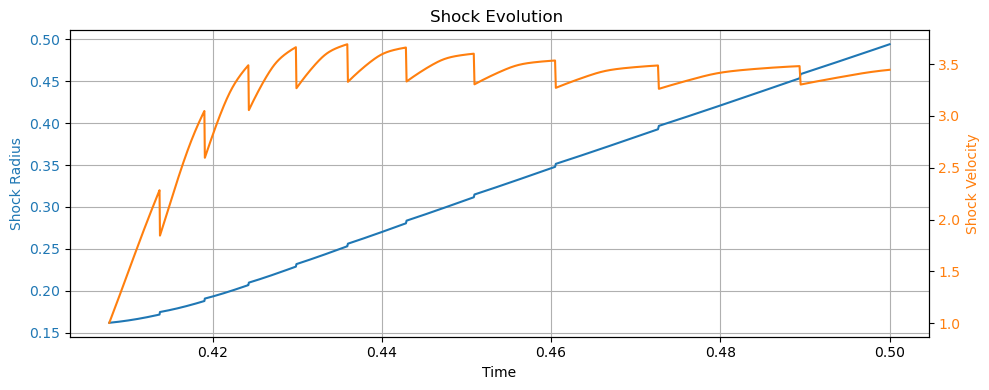

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- Convert to arrays ---
r_arr = np.array(r_arr)   # (Nt, N+1)
v_arr = np.array(v_arr)   # (Nt, N+1)
t     = np.array(t_arr)   # (Nt,)

# Optional: if cs is spatial-temporal field
# cs_arr = np.array(cs_arr)  # (Nt, N+1)

shock_radius = []
shock_velocity = []
t_valid = []

# --- Shock detection + physical filtering ---
for i in range(len(t)):

    dv = np.diff(v_arr[i])
    dr = np.diff(r_arr[i])

    # Avoid division instability
    dv_dr = np.abs(dv / (dr + 1e-12))

    # Shock index (strongest gradient)
    idx = np.argmax(dv_dr)

    # Cell-centered values
    r_shock = 0.5 * (r_arr[i, idx] + r_arr[i, idx+1])
    v_shock = 0.5 * (v_arr[i, idx] + v_arr[i, idx+1])

    # --- Sound speed at shock ---
    if 'cs_arr' in globals():
        cs_local = 0.5 * (cs_arr[i, idx] + cs_arr[i, idx+1])
    else:
        cs_local = cs   # scalar fallback

    # --- Physical condition: supersonic shock ---
    if v_shock > cs_local:
        shock_radius.append(r_shock)
        shock_velocity.append(v_shock)
        t_valid.append(t[i])

# Convert to arrays
shock_radius = np.array(shock_radius)
shock_velocity = np.array(shock_velocity)
t_valid = np.array(t_valid)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(t_valid, shock_radius)
ax1.set_xlabel("Time")
ax1.set_ylabel("Shock Radius", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(t_valid, shock_velocity, color='tab:orange')
ax2.set_ylabel("Shock Velocity", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Shock Evolution ")
plt.tight_layout()
plt.show()

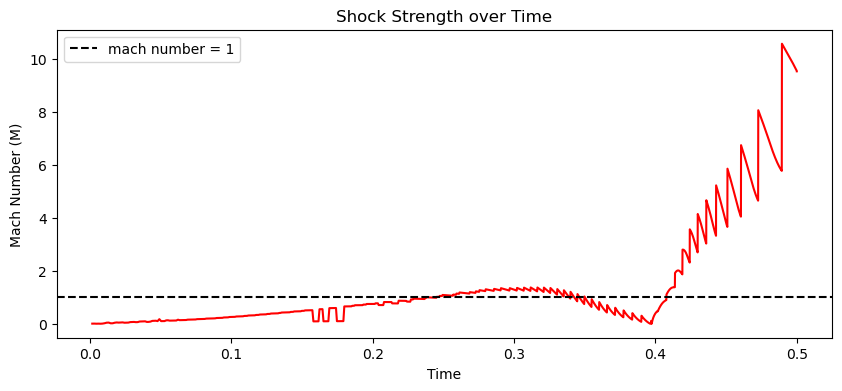

In [26]:
# Assuming cs_arr has shape (Nt, N+1) like v_arr
shock_mach = []

for i in range(len(t)):
    # Use the same idx you found for the shock
    dv_dr = np.abs(np.diff(v_arr[i]) / (np.diff(r_arr[i]) + 1e-12))
    idx = np.argmax(dv_dr)
    
    v_s = np.abs(v_arr[i, idx])
    c_s = cs_arr[i, idx] # Sound speed at the shock front
    
    shock_mach.append(v_s / c_s)

# Plotting the Mach Number
plt.figure(figsize=(10, 4))
plt.plot(t, shock_mach, color='red')
plt.axhline(1.0, color='black', linestyle='--',label='mach number = 1') # The supersonic threshold
plt.ylabel("Mach Number (M)")
plt.xlabel("Time")
plt.title("Shock Strength over Time")
plt.legend()
plt.show()

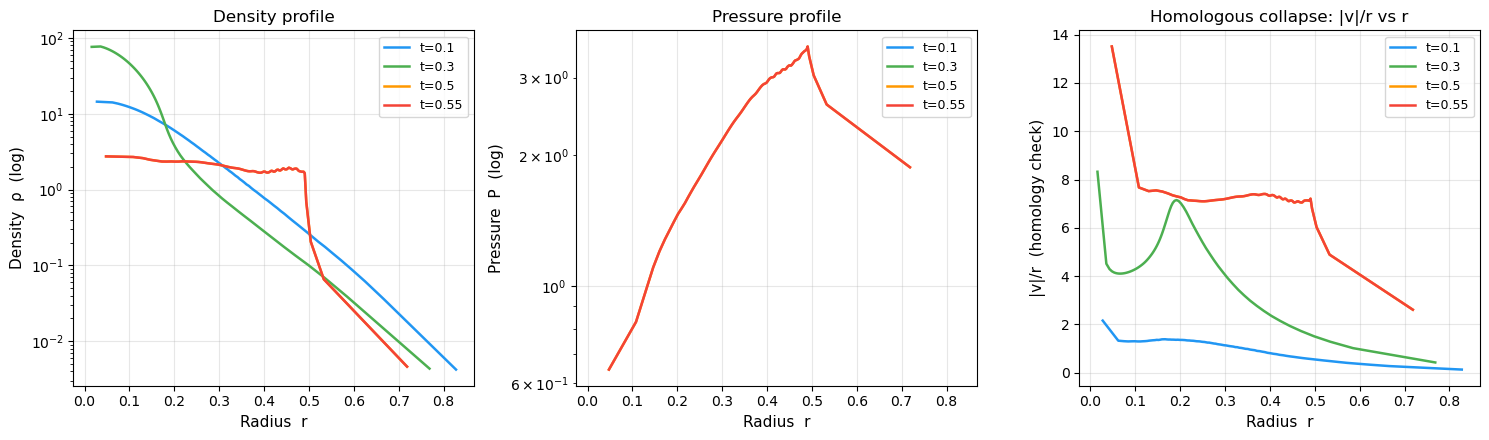

In [36]:
# --- Figure 4: Radial Profiles at Snapshots ---
snap_times = [0.10, 0.30, 0.50, 0.55]
snap_colors = ['#2196F3','#4CAF50','#FF9800','#F44336']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for stime, scol in zip(snap_times, snap_colors):
    idx = np.argmin(np.abs(t_arr - stime))
    r_c = 0.5 * (r_arr[idx, 1:] + r_arr[idx, :-1])
    mask = r_c > 0

    axes[0].semilogy(r_c[mask], rho_arr[idx][mask],
                     color=scol, lw=1.8, label=f't={stime}')
    axes[1].semilogy(r_c[mask], v_arr[idx,1:][mask],
                     color=scol, lw=1.8, label=f't={stime}')
    axes[2].plot(r_c[mask], np.abs(v_arr[idx, 1:][mask]) / r_c[mask],
                 color=scol, lw=1.8, label=f't={stime}')

for ax, ylabel, title in zip(axes,
        ['Density  ρ  (log)', 'Pressure  P  (log)', '|v|/r  (homology check)'],
        ['Density profile', 'Pressure profile', 'Homologous collapse: |v|/r vs r']):
    ax.set_xlabel('Radius  r', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)



plt.tight_layout()
plt.savefig('fig4_profiles.png', dpi=150, bbox_inches='tight')
plt.show()